# Problem Sheet 1 — Yang Cheng, yacheng@mpia.de

I load everything with the code from the course inputs notebook (`illustris_python`, plus `h5py` for the snapshot headers).

entries reference are from : https://www.tng-project.org/data/docs/specifications/

In [19]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import h5py
#I still used the illustris python to load data (refered to the code from the intro notebook)
import illustris_python as il

## 1.1 — The distribution of dark matter haloes

Halo masses and positions from TNG100-3Dark at z=0: one dot per halo, then dots sized by mass, then different mass cuts.

Units: mass $\times\,10^{10}/h$ gives $M_\odot$, positions $\times\,a/(1000h)$ give Mpc. At z=0, a=1 anyway.

In [20]:
basePath = '/home/tnguser/sims.TNG/TNG100-3-Dark/output'
snap = 99

header = il.groupcat.loadHeader(basePath, snap)
h = header['HubbleParam']
a = header['Time']

#the alternative 'elegant' way
#I took this load function from the intro notebook
data = il.groupcat.loadHalos(basePath, snap, fields=['GroupMass', 'GroupPos'])

halo_mass = data['GroupMass'] * 1e10 / h          # Msun
halo_coords = data['GroupPos'] * a / h / 1000     # Mpc
halo_x, halo_y = halo_coords[:, 0], halo_coords[:, 1]
halo_box = header['BoxSize'] * a / h / 1000

#just to verify if the data is the correct one
print('Redshift:', header['Redshift'])
print('Number of haloes:', len(halo_mass))
print(f'Mass range: {halo_mass.min():.3e} to {halo_mass.max():.3e} Msun')
print(f'Box size: {halo_box:.3f} Mpc')

Redshift: 2.220446049250313e-16
Number of haloes: 94738
Mass range: 1.814e+10 to 6.187e+14 Msun
Box size: 110.717 Mpc


### a) Plot one dot point per halo, projected along z

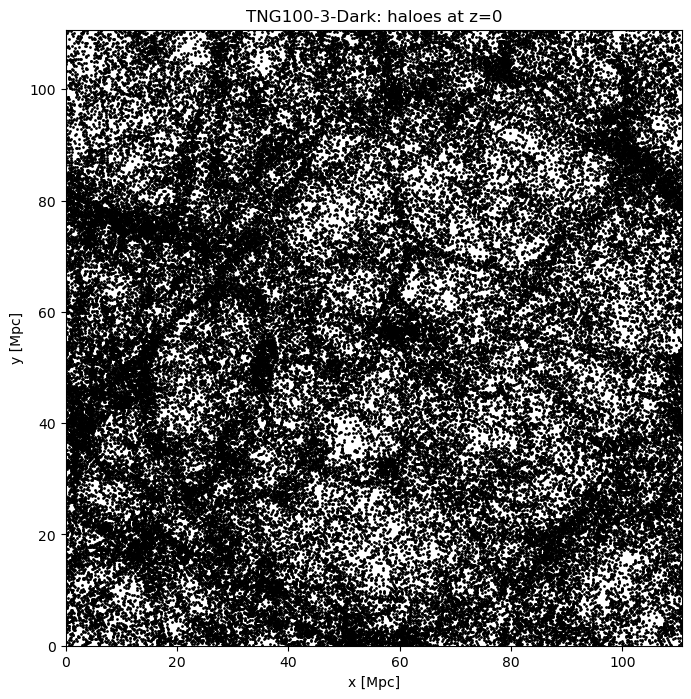

In [21]:
fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(x=halo_x, y=halo_y, s=1, color='black')
ax.set(xlabel='x [Mpc]', ylabel='y [Mpc]', xlim=(0, halo_box), ylim=(0, halo_box),
       title='TNG100-3-Dark: haloes at z=0')
ax.set_aspect('equal')
plt.show()

### b) Plot one circle per halo with size proportional to halo mass

I define a size factor manually just to make the circles visually reasonable:

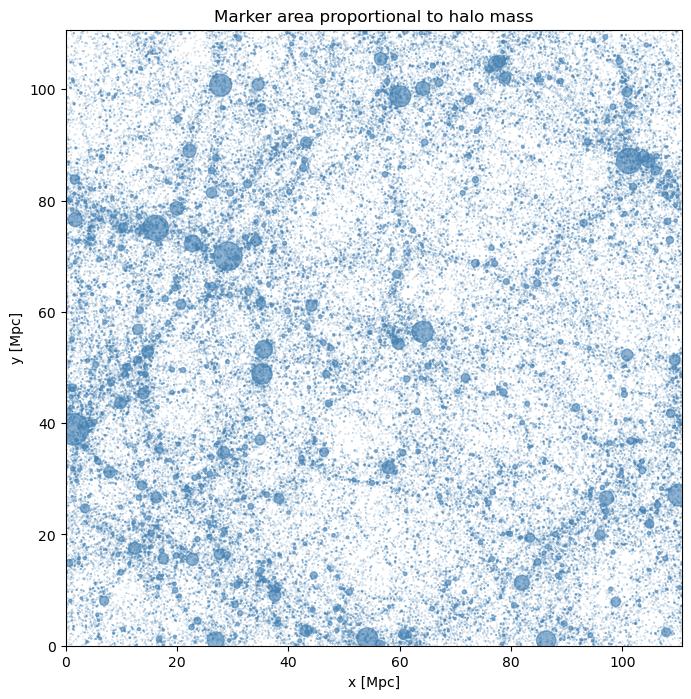

In [22]:
size = 500 * halo_mass / halo_mass.max()

fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(x=halo_x, y=halo_y, s=size, color='steelblue', alpha=0.6)
ax.set(xlabel='x [Mpc]', ylabel='y [Mpc]', xlim=(0, halo_box), ylim=(0, halo_box),
       title='Marker area proportional to halo mass')
ax.set_aspect('equal')
plt.show()

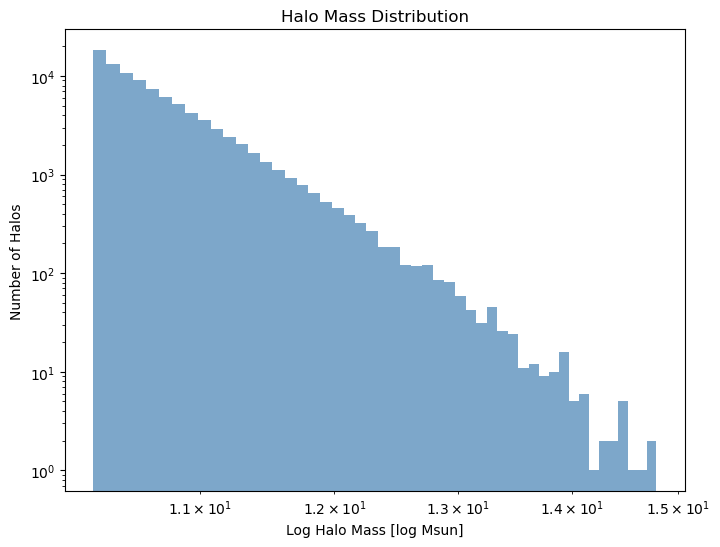

In [23]:
#to check the mass range of the halos, I plot the histogram of the halo mass distribution
plt.figure(figsize=(8, 6))
plt.hist(np.log10(halo_mass), bins=50, color='steelblue', alpha=0.7)
plt.xlabel('Log Halo Mass [log Msun]')
plt.ylabel('Number of Halos')
plt.title('Halo Mass Distribution')
plt.xscale('log')
plt.yscale('log')
plt.show()

### c) Plot the halo points with different minimum mass cuts

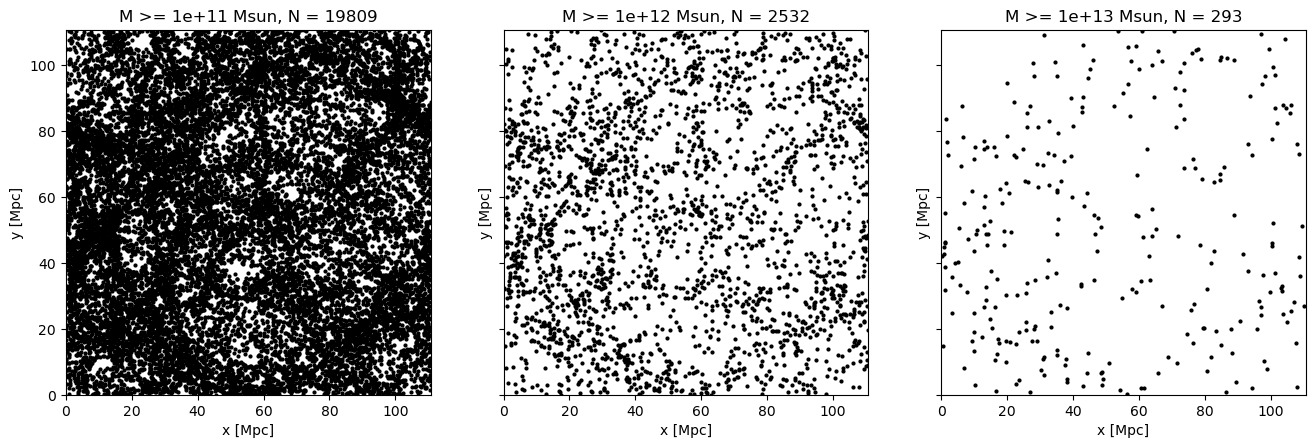

In [24]:
mass_cuts = [1e11, 1e12, 1e13]

fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharex=True, sharey=True)
for ax, cut in zip(axes, mass_cuts):
    select = np.where(halo_mass >= cut)
    ax.scatter(x=halo_x[select], y=halo_y[select], s=4, color='black')
    ax.set(xlabel='x [Mpc]', ylabel='y [Mpc]', xlim=(0, halo_box), ylim=(0, halo_box),
           title=f'M >= {cut:.0e} Msun, N = {len(select[0])}')
    ax.set_aspect('equal')
plt.show()

### Plot the halo points with differentmass bins

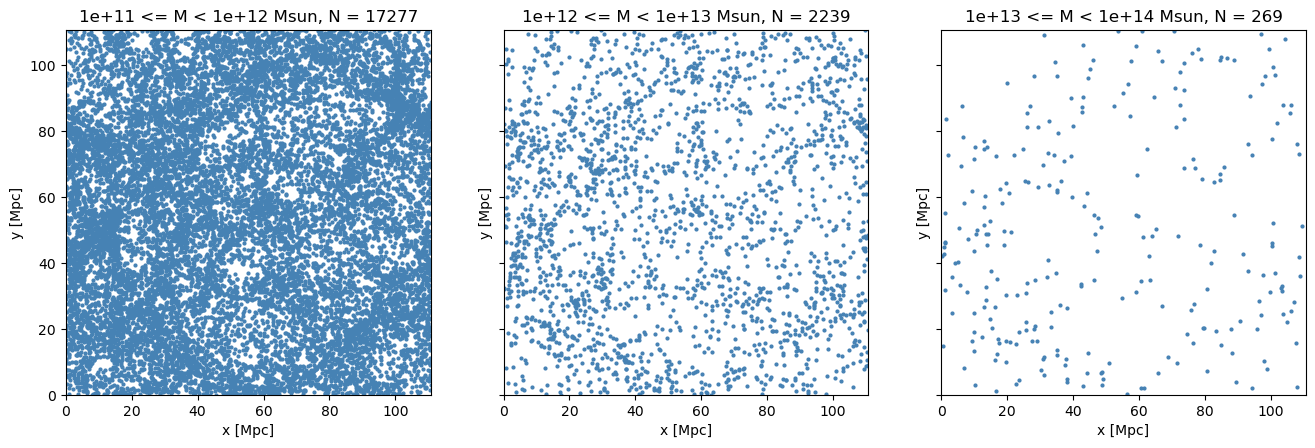

In [25]:
#I manually set 3 mass bins for plot
mass_bins = [1e11,1e12, 1e13, 1e14]

fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharex=True, sharey=True)
for ax, low, high in zip(axes, mass_bins[:-1], mass_bins[1:]):
    select = np.where((halo_mass >= low) & (halo_mass < high))
    ax.scatter(x=halo_x[select], y=halo_y[select], s=4, color='steelblue')
    ax.set(xlabel='x [Mpc]', ylabel='y [Mpc]', xlim=(0, halo_box), ylim=(0, halo_box),
           title=f'{low:.0e} <= M < {high:.0e} Msun, N = {len(select[0])}')
    ax.set_aspect('equal')
plt.show()

### 1.1 Small discussion of the plots

Halo masses go from **[min]** to **[max]** Msun.

Based on the plots of all the halos in this dataset, I can already see a large-scale structure of those halos are organized/locally clustered in filaments in the simulation box. The different mass cuts shows that the number density of halos decreases with increasing halo mass and the distribution becomes more sparse.

## 1.2 — The distribution of dark matter particles

Now the particles of TNG50-4-Dark at z=0: scatter plot, 2D histograms with a few pixel sizes, and then the same histogram turned into a surface density.

All DM particles have the same mass, which sits in `MassTable[1]` of the snapshot header. 

In [26]:
basePath = '/home/tnguser/sims.TNG/TNG50-4-Dark/output'
snap = 99

with h5py.File(basePath + '/snapdir_%03d/snap_%03d.%s.hdf5' % (snap, snap, 0), 'r') as f:
    header = dict(f['Header'].attrs)
h = header['HubbleParam']
a = header['Time']
dm_box = header['BoxSize'] * a / h / 1000          # Mpc
dm_mass = header['MassTable'][1] * 1e10 / h        # Msun per particle

Coordinates = il.snapshot.loadSubset(basePath, snap, partType=1, fields=['Coordinates'])
Coordinates = Coordinates * a / h / 1000           # Mpc
x_axis, y_axis = Coordinates[:, 0], Coordinates[:, 1]
nparticles = len(Coordinates)

print('Redshift:', header['Redshift'])
print(f'Particle mass: {dm_mass:.3e} Msun')
print(f'Box size: {dm_box:.3f} Mpc')
print('Number of particles:', nparticles)
print(f'Total mass: {nparticles * dm_mass:.3e} Msun')

Redshift: 2.220446049250313e-16
Particle mass: 2.757e+08 Msun
Box size: 51.668 Mpc
Number of particles: 19683000
Total mass: 5.426e+15 Msun


### a) One dot per ***particle***

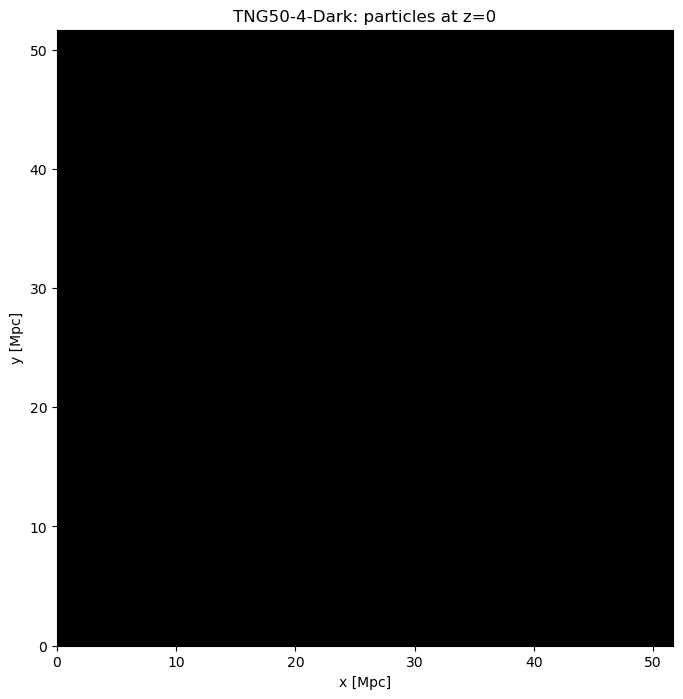

In [27]:
fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(x=x_axis, y=y_axis, s=0.01, color='black')
ax.set(xlabel='x [Mpc]', ylabel='y [Mpc]', xlim=(0, dm_box), ylim=(0, dm_box),
       title='TNG50-4-Dark: particles at z=0')
ax.set_aspect('equal')
plt.show()

Just by plotting all particle coordinates in 2D, I can barely see anything. 

### b) 2D histograms with different pixel sizes

Each pixel is just a particle count. The three panels have their own color scale and their own pixel area, so I can't compare colors between them.

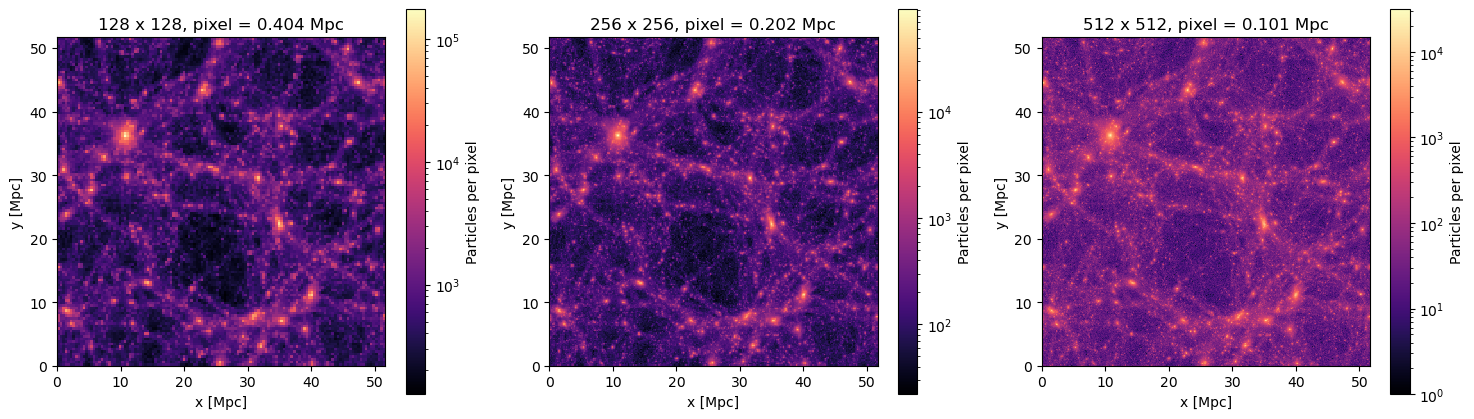

In [28]:
nbins_list = [128, 256, 512]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, nbins in zip(axes, nbins_list):
    counts, xedges, yedges, image = ax.hist2d(x=x_axis, y=y_axis, bins=nbins,
        range=[[0, dm_box], [0, dm_box]], norm=mpl.colors.LogNorm(), cmap='magma')
    ax.set(xlabel='x [Mpc]', ylabel='y [Mpc]',
           title=f'{nbins} x {nbins}, pixel = {dm_box / nbins:.3f} Mpc')
    ax.set_aspect('equal')
    fig.colorbar(image, ax=ax, label='Particles per pixel')
plt.show()

By 2D binning the particles, the 2d histogram finally shows some large-scale structure of what I assume is something similar to the cosmic web, i.e. the filaments, the voids and the clusters of DM particles.

### b.2) Surface density map

The above histograms show density maps in the units of particles per pixel (or 2D bin of the histogram). To convert to a surface density in $M_\odot/\mathrm{Mpc}^2$, we need to convert both the particle counts and the bin area to physical units of $M_\odot$ and $\mathrm{Mpc}^2$. The particle counts are just $N_{ij}$ in $i,j$ and the bin area is $A_{\rm pixel}=(L/N_{\rm bins})^2$, where $L$ is the box size and $N_{\rm bins}$ is the number of bins along one axis. The mass of each particle is $m_{\rm DM}$, so the surface density in each pixel is

$\Sigma_{ij}=N_{ij}\,m_{\rm DM}/A_{\rm pixel}$ with $A_{\rm pixel}=(L/N_{\rm bins})^2$.

So I just multiply every particle by a factor $m_{\rm DM}/A_{\rm pixel}$ and hist2d should return 2d mass density in $M_\odot/\mathrm{Mpc}^2$

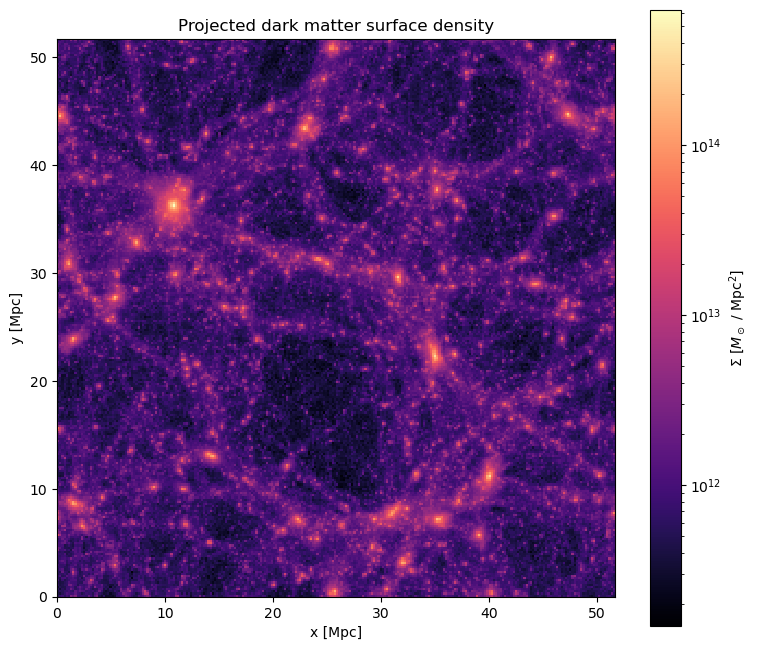

In [29]:
nbins = 256
pixel_area = (dm_box / nbins)**2
weights = np.full(nparticles, dm_mass / pixel_area)

fig, ax = plt.subplots(figsize=(9, 8))
Sigma, xedges, yedges, image = ax.hist2d(x=x_axis, y=y_axis, weights=weights, bins=nbins,
    range=[[0, dm_box], [0, dm_box]], norm=mpl.colors.LogNorm(), cmap='magma')
ax.set(xlabel='x [Mpc]', ylabel='y [Mpc]', title='Projected dark matter surface density')
ax.set_aspect('equal')
fig.colorbar(image, ax=ax, label=r'$\Sigma$ [$M_\odot$ / Mpc$^2$]')
plt.show()

### c) Optional: Gaussian smoothing

`sigma=1` means one pixel, and `mode='wrap'` because the box is periodic.

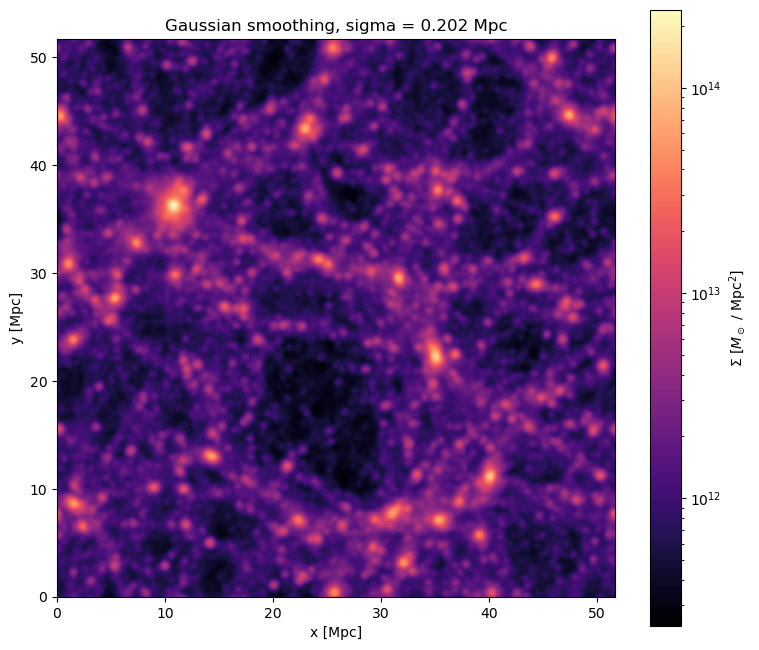

In [30]:
from scipy.ndimage import gaussian_filter

Sigma_smooth = gaussian_filter(Sigma, sigma=1.0, mode='wrap')

fig, ax = plt.subplots(figsize=(9, 8))
image = ax.imshow(np.ma.masked_less_equal(Sigma_smooth.T, 0), origin='lower',
    extent=[0, dm_box, 0, dm_box], norm=mpl.colors.LogNorm(), cmap='magma')
ax.set(xlabel='x [Mpc]', ylabel='y [Mpc]',
       title=f'Gaussian smoothing, sigma = {dm_box / nbins:.3f} Mpc')
ax.set_aspect('equal')
fig.colorbar(image, ax=ax, label=r'$\Sigma$ [$M_\odot$ / Mpc$^2$]')
plt.show()

### 1.2 a small summary

In the scatter plot **[describe overlap / how much is visible]**, in the histograms **[describe the structures]**.

Smaller pixels resolve more, but they also hold fewer particles, so they get noisier in low density regions. We have also computed the surface density in unit of both pixel per bin and mass per bin area, integrated through the whole depth of the box. The gaussian smoothing I believe reduces the spatial resolution, but it also reduces the noise in low density regions.

## 2. The distribution of matter within haloes

### 2.1 —

Load the mass and coordinates of the dark-matter particles that belong to a given halo from the TNG100-3-Dark simulation at z=0. For example, choose the 5th object in the Group list or the 10th, or whichever:

- Make an image of such halo, i.e. make a map of its dark-matter particles in a random projection. Transform such map of particles in a map of dark-matter densities (use a 2D histogramming). What densities are we looking at in Msun/kpc^2? How would you describe the density field?
- Compare different projections of the same halo, i.e. the same halo projected along different simulation axes. Is it spherical?
- Compare the dark-matter density maps of haloes of very different masses.

NOTE: no need to use the illustris_python for this.

### My setup

I just randomly take halo #4 (5-th object) from TNG100-3-Dark. I still use the il python package from the introduction notebook (bcs it looks better for coding). `il.snapshot.loadHalo` gives me the particles of one FoF group straight away, essentially with segmentation so I only have to shift them to `GroupPos`, wrap them around the periodic box and convert to physical kpc.

In [31]:
basePath = '/home/tnguser/sims.TNG/TNG100-3-Dark/output'
snap = 99
haloID = 4     # 5th object in the Group list

with h5py.File(basePath + '/snapdir_%03d/snap_%03d.%s.hdf5' % (snap, snap, 0), 'r') as f:
    header = dict(f['Header'].attrs)
h = header['HubbleParam']
a = header['Time']
box = header['BoxSize']                        # ckpc/h, for the periodic wrap
pmass = header['MassTable'][1] * 1e10 / h      # Msun per particle

halos = il.groupcat.loadHalos(basePath, snap, fields=['GroupMass', 'GroupPos'])
group_mass = halos['GroupMass'] * 1e10 / h

def load_halo(haloID):
    """DM particles of one halo, relative to its centre, in physical kpc."""
    pos = il.snapshot.loadHalo(basePath, snap, haloID, partType=1, fields=['Coordinates'])
    d = pos - halos['GroupPos'][haloID]
    d = (d + box / 2) % box - box / 2          # periodic box
    return d * a / h

coords = load_halo(haloID)
extent = 1.05 * np.abs(coords).max()           # half-width of the maps, kpc

print(f'Halo {haloID}: M = {group_mass[haloID]:.3e} Msun, N_DM = {len(coords)}')
print(f'DM particle mass: {pmass:.3e} Msun')
print(f'Map half-width: {extent:.2f} kpc')

Halo 4: M = 3.113e+14 Msun, N_DM = 549098
DM particle mass: 5.668e+08 Msun
Map half-width: 3665.75 kpc


### a) Particle map and surface density

Same procedue as in 1.2, just in kpc:

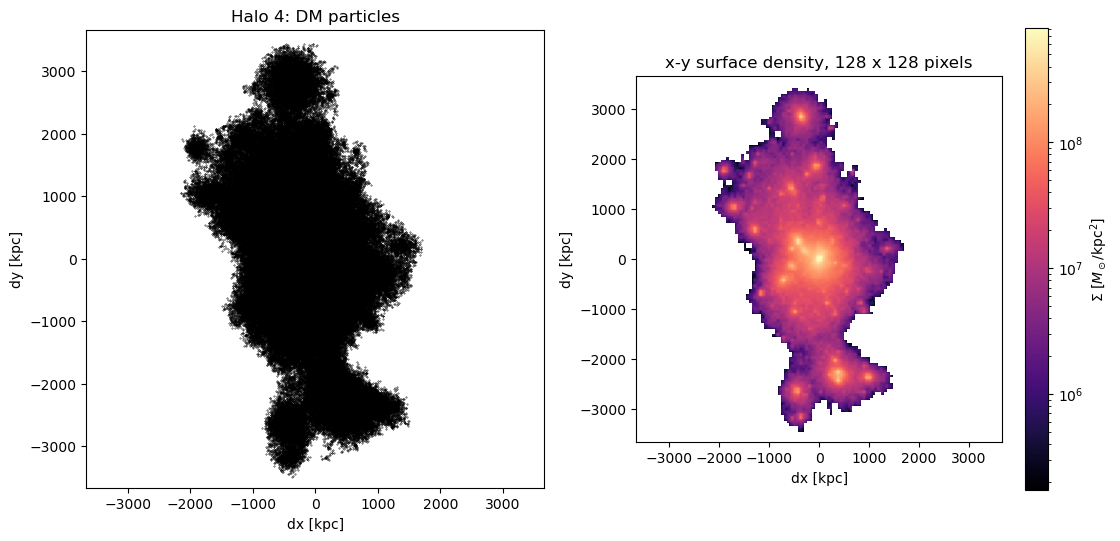

Pixel size: 57.28 kpc
Mass from map: 3.113e+14 Msun


In [32]:
nbins = 128

def surface_density(coords, proj, extent, nbins=128):
    counts, _, _ = np.histogram2d(coords[:, proj[0]], coords[:, proj[1]], bins=nbins,
        range=[[-extent, extent], [-extent, extent]])
    return counts * pmass / (2 * extent / nbins)**2     # Msun/kpc^2

sigma = surface_density(coords, (0, 1), extent, nbins)

fig, axes = plt.subplots(1, 2, figsize=(13, 6))
axes[0].scatter(x=coords[:, 0], y=coords[:, 1], s=0.1, color='black')
axes[0].set_title(f'Halo {haloID}: DM particles')
image = axes[1].imshow(np.ma.masked_less_equal(sigma.T, 0), origin='lower',
    extent=[-extent, extent, -extent, extent], norm=mpl.colors.LogNorm(), cmap='magma')
axes[1].set_title(f'x-y surface density, {nbins} x {nbins} pixels')
for ax in axes:
    ax.set(xlabel='dx [kpc]', ylabel='dy [kpc]', xlim=(-extent, extent), ylim=(-extent, extent))
    ax.set_aspect('equal')
fig.colorbar(image, ax=axes[1], label=r'$\Sigma$ [$M_\odot$/kpc$^2$]')
plt.show()

print(f'Pixel size: {2 * extent / nbins:.2f} kpc')
print(f'Mass from map: {sigma.sum() * (2 * extent / nbins)**2:.3e} Msun')

### b) Different projections

x-y, x-z and y-z with the same field of view, the same pixels and the same color scale. If it looks round in one projection that still doesn't make it round in 3D.

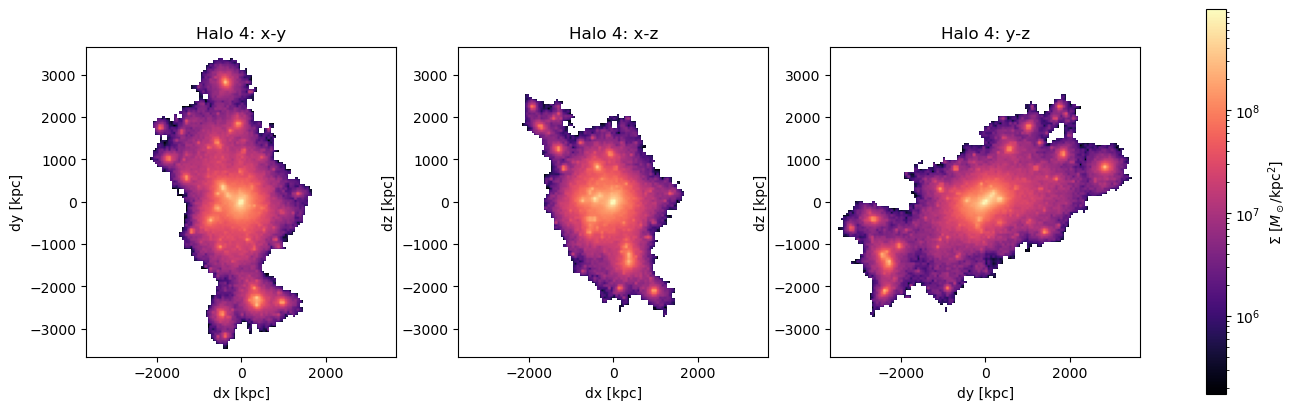

In [33]:
projections = [(0, 1), (0, 2), (1, 2)]
names = ['x', 'y', 'z']

maps = [surface_density(coords, proj, extent, nbins) for proj in projections]
one_particle = pmass / (2 * extent / nbins)**2      # density of a single particle in a pixel
norm = mpl.colors.LogNorm(vmin=one_particle, vmax=max(m.max() for m in maps))

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
for ax, proj, density in zip(axes, projections, maps):
    image = ax.imshow(np.ma.masked_less_equal(density.T, 0), origin='lower',
        extent=[-extent, extent, -extent, extent], norm=norm, cmap='magma')
    u, v = names[proj[0]], names[proj[1]]
    ax.set(xlabel=f'd{u} [kpc]', ylabel=f'd{v} [kpc]', title=f'Halo {haloID}: {u}-{v}')
    ax.set_aspect('equal')
fig.colorbar(image, ax=list(axes), label=r'$\Sigma$ [$M_\odot$/kpc$^2$]')
plt.show()

### c) Haloes of very different masses

I pick the haloes closest to 1e12, 1e13 and 1e14 Msun and plot them with the same field of view, pixel size and color scale, so the maps are directly comparable. The light ones then only fill a small part of the panel.

Halo 2531: M = 1.000e+12 Msun, N_DM = 1765
Halo 293: M = 9.998e+12 Msun, N_DM = 17638
Halo 23: M = 1.004e+14 Msun, N_DM = 177084


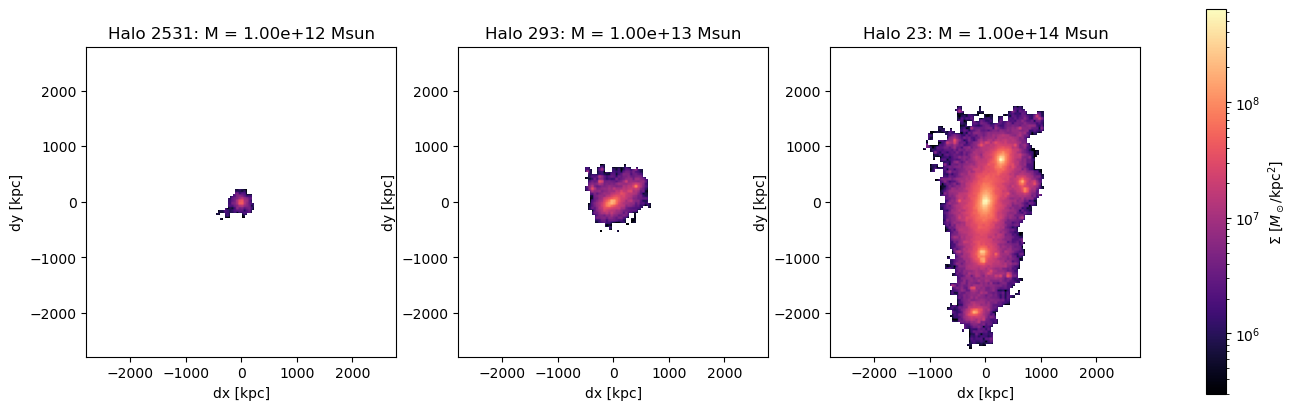

Common pixel size: 43.61 kpc


In [34]:
#I use argmin to find the halo closest to the target I manually set
targets = [1e12, 1e13, 1e14]     # Msun
ids = [int(np.argmin(np.abs(group_mass - target))) for target in targets]

#again load halo
coords_list = [load_halo(i) for i in ids]
ext = 1.05 * max(np.abs(c).max() for c in coords_list)
maps = [surface_density(c, (0, 1), ext, nbins) for c in coords_list]
norm = mpl.colors.LogNorm(vmin=pmass / (2 * ext / nbins)**2, vmax=max(m.max() for m in maps))

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
for ax, i, c, density in zip(axes, ids, coords_list, maps):
    image = ax.imshow(np.ma.masked_less_equal(density.T, 0), origin='lower',
        extent=[-ext, ext, -ext, ext], norm=norm, cmap='magma')
    ax.set(xlabel='dx [kpc]', ylabel='dy [kpc]',
           title=f'Halo {i}: M = {group_mass[i]:.2e} Msun')
    ax.set_aspect('equal')
    print(f'Halo {i}: M = {group_mass[i]:.3e} Msun, N_DM = {len(c)}')
fig.colorbar(image, ax=list(axes), label=r'$\Sigma$ [$M_\odot$/kpc$^2$]')
plt.show()

print(f'Common pixel size: {2 * ext / nbins:.2f} kpc')

### 2.1 a small description of what I see


The 5th Halo in this dataset looks asymmetry (at least not spherical). Just between x-y, x-z and y-z projection, it is very hard to delineate the true 3D distribution of this halo. Intuitively the morphology seems not spherical but elongated along one direction. By ploting three halos with different masses directly demonstrate a possible correlation between mass and size (but just based on one projection). By setting all three halo density map to the same color scale, I can also see that the density of the halo increases with increasing mass, which is consistent with my expectation.